Number of images: 900


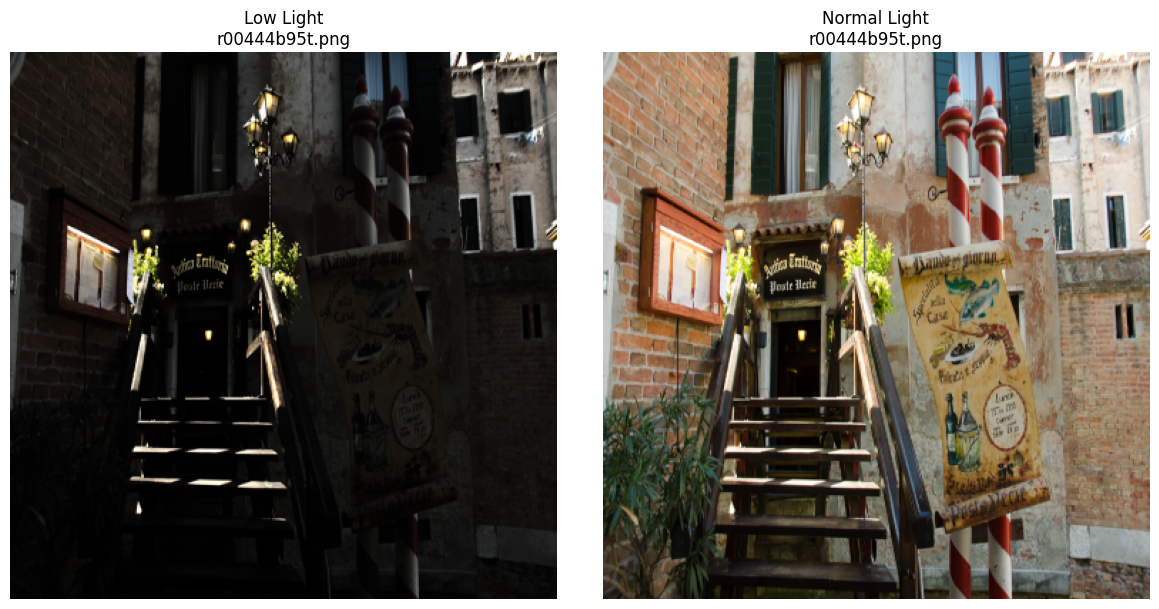

In [6]:
import os
import cv2
import matplotlib.pyplot as plt

low_path = "LOL-v2/synthetic/train/low"
high_path = "LOL-v2/synthetic/train/normal"

image_names = sorted(os.listdir(low_path))

print("Number of images:", len(image_names))

# ---- CHANGE THIS NUMBER EACH TIME ----
idx = 3
# --------------------------------------

# Get image names
low_img_name = image_names[idx]
high_img_name = image_names[idx]

# Read images
low_img = cv2.imread(os.path.join(low_path, low_img_name))
high_img = cv2.imread(os.path.join(high_path, high_img_name))

# Convert BGR -> RGB
low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

# Show side by side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(low_img)
plt.title(f"Low Light\n{low_img_name}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_img)
plt.title(f"Normal Light\n{high_img_name}")
plt.axis("off")

plt.tight_layout()
plt.show()

Total Images: 900


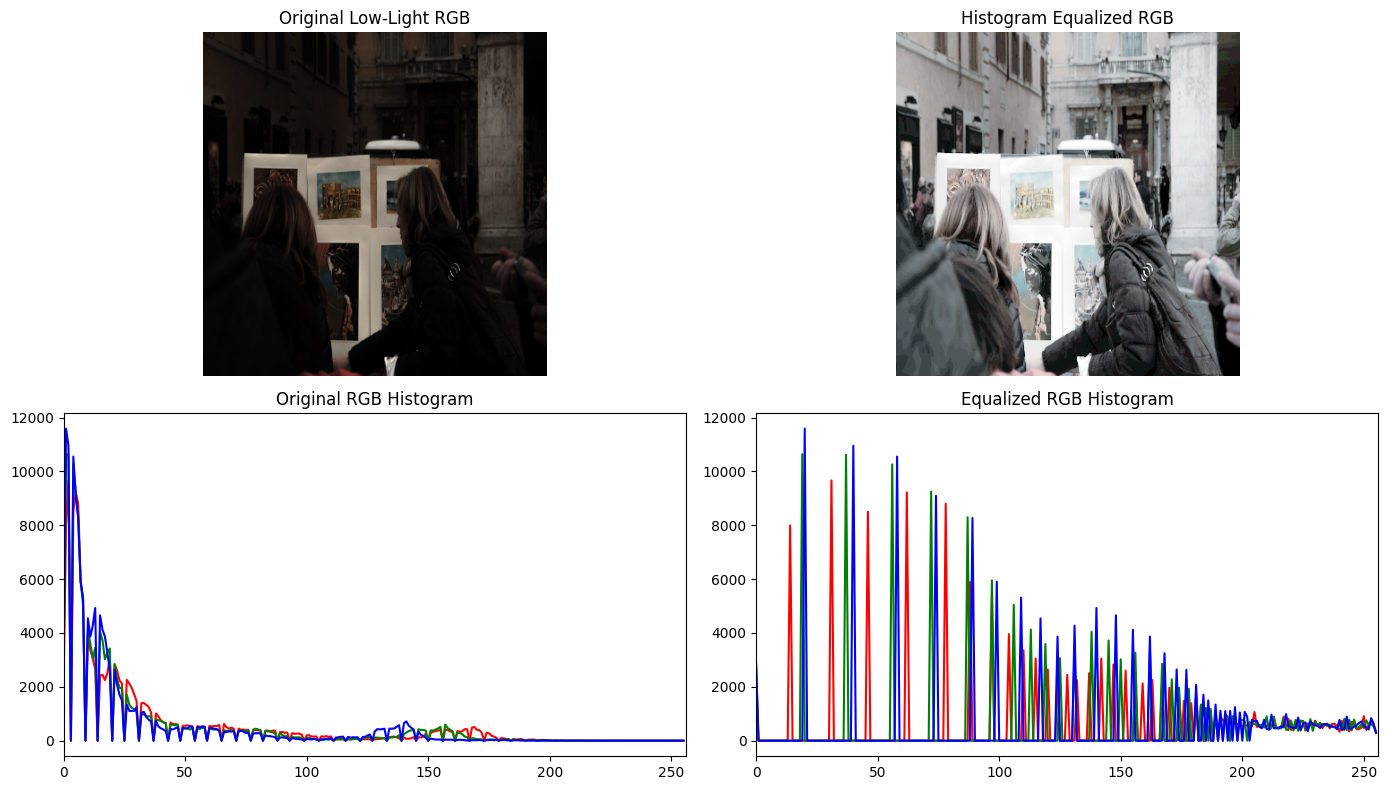

In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Paths
# =========================
low_path = "LOL-v2/synthetic/train/low"
high_path = "LOL-v2/synthetic/train/normal"

image_names = sorted(os.listdir(low_path))

print("Total Images:", len(image_names))

# =========================
# Select image index
# Change this each run
# =========================
idx = 500

# =========================
# Read image
# =========================
img_name = image_names[idx]

low_img_path = os.path.join(low_path, img_name)

img = cv2.imread(low_img_path)

# BGR -> RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# Histogram Equalization on RGB channels separately
# =========================

# Split channels
r, g, b = cv2.split(img_rgb)

# Apply histogram equalization independently
r_eq = cv2.equalizeHist(r)
g_eq = cv2.equalizeHist(g)
b_eq = cv2.equalizeHist(b)

# Merge back
img_eq = cv2.merge((r_eq, g_eq, b_eq))

# =========================
# Visualization
# =========================

plt.figure(figsize=(14, 8))

# Original
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Low-Light RGB")
plt.axis("off")

# Enhanced
plt.subplot(2, 2, 2)
plt.imshow(img_eq)
plt.title("Histogram Equalized RGB")
plt.axis("off")

# =========================
# Histograms
# =========================

colors = ['r', 'g', 'b']

# Original Histogram
plt.subplot(2, 2, 3)

for i, color in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=color)

plt.title("Original RGB Histogram")
plt.xlim([0, 256])

# Enhanced Histogram
plt.subplot(2, 2, 4)

for i, color in enumerate(colors):
    hist = cv2.calcHist([img_eq], [i], None, [256], [0, 256])
    plt.plot(hist, color=color)

plt.title("Equalized RGB Histogram")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

Total Images: 900


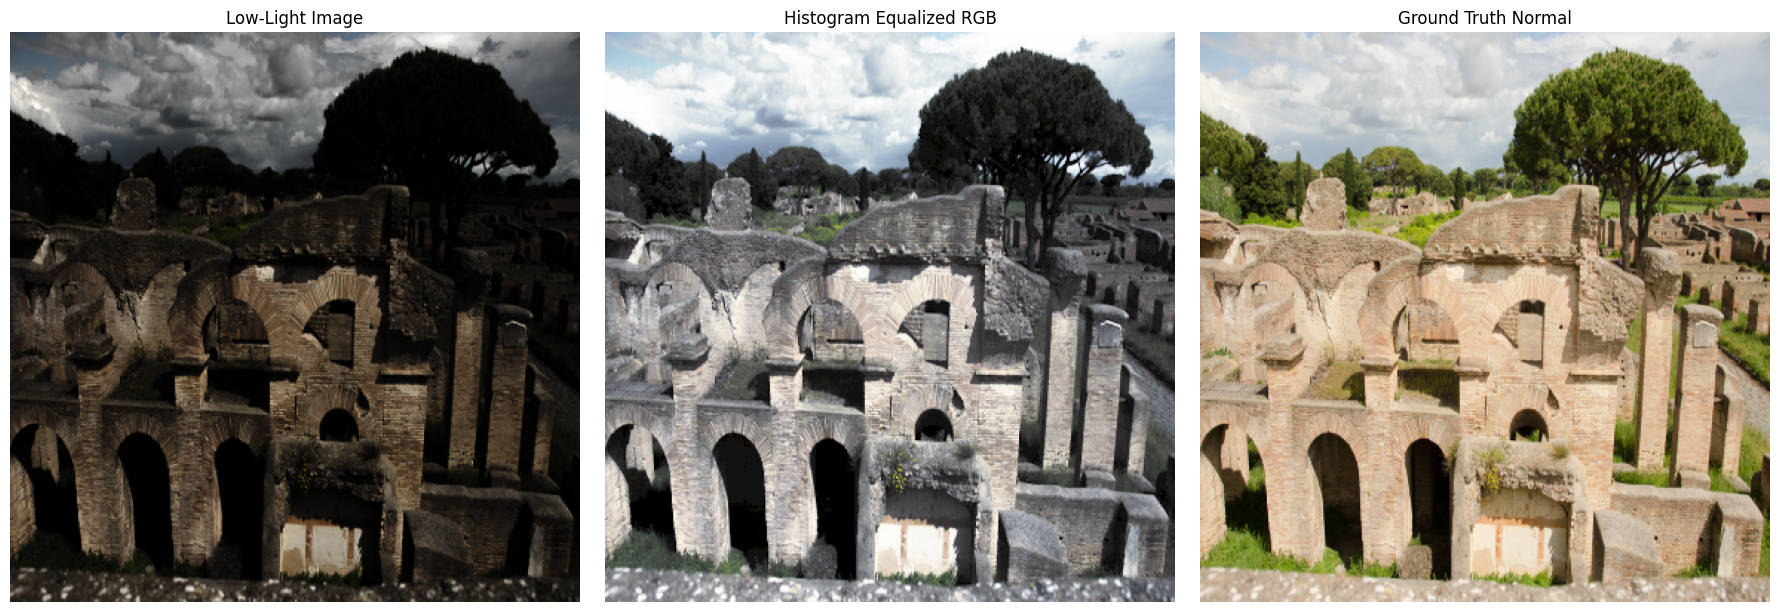

In [13]:
import os
import cv2
import matplotlib.pyplot as plt

# =========================
# Paths
# =========================
low_path = "LOL-v2/synthetic/train/low"
high_path = "LOL-v2/synthetic/train/normal"

image_names = sorted(os.listdir(low_path))

print("Total Images:", len(image_names))

# =========================
# Select image index
# Change this every run
# =========================
idx = 600

# =========================
# Read images
# =========================
img_name = image_names[idx]

low_img_path = os.path.join(low_path, img_name)
high_img_path = os.path.join(high_path, img_name)

low_img = cv2.imread(low_img_path)
high_img = cv2.imread(high_img_path)

# BGR -> RGB
low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

# =========================
# Histogram Equalization on RGB
# =========================

r, g, b = cv2.split(low_img)

r_eq = cv2.equalizeHist(r)
g_eq = cv2.equalizeHist(g)
b_eq = cv2.equalizeHist(b)

hist_eq_img = cv2.merge((r_eq, g_eq, b_eq))

# =========================
# Visualization
# =========================

plt.figure(figsize=(18, 6))

# LOW IMAGE
plt.subplot(1, 3, 1)
plt.imshow(low_img)
plt.title("Low-Light Image")
plt.axis("off")

# HIST EQ IMAGE
plt.subplot(1, 3, 2)
plt.imshow(hist_eq_img)
plt.title("Histogram Equalized RGB")
plt.axis("off")

# NORMAL IMAGE
plt.subplot(1, 3, 3)
plt.imshow(high_img)
plt.title("Ground Truth Normal")
plt.axis("off")

plt.tight_layout()
plt.show()

Total Images: 900


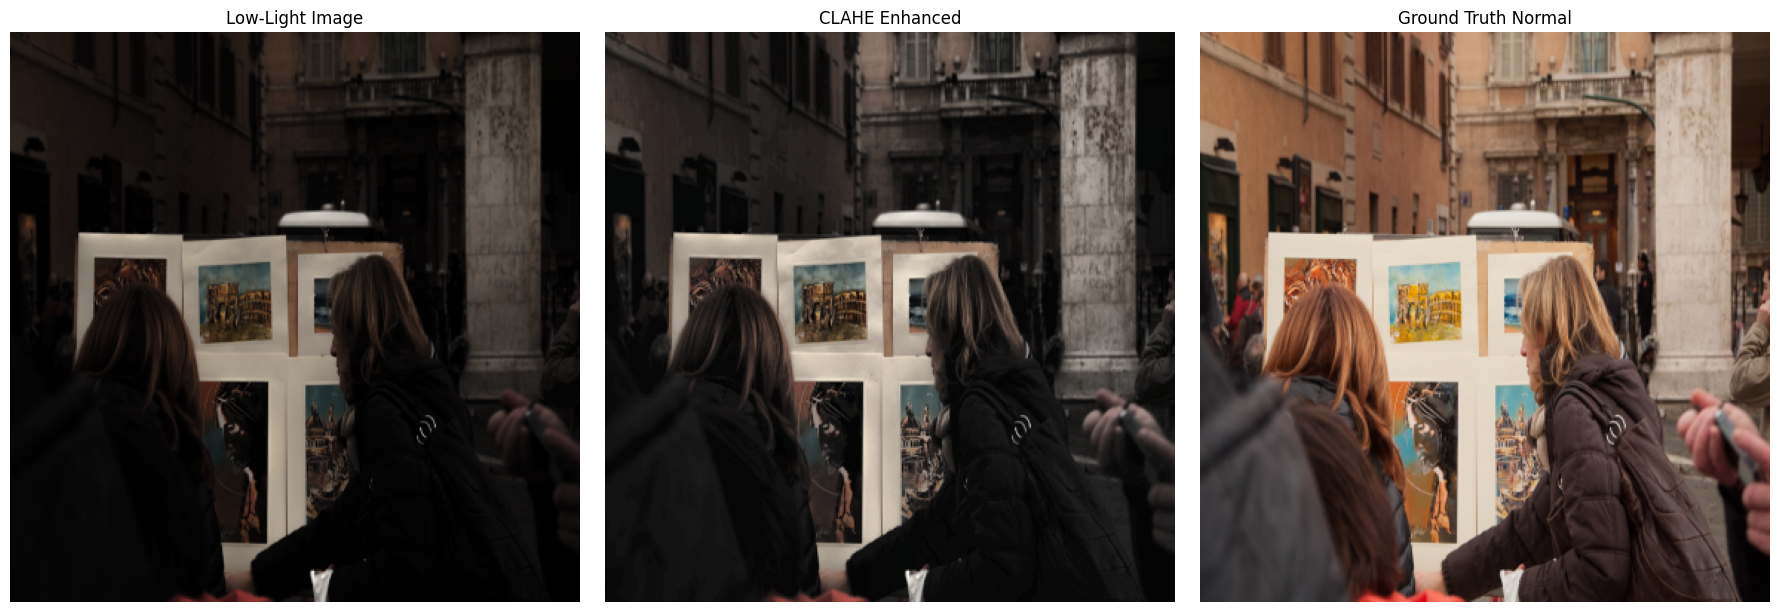

In [18]:
import os
import cv2
import matplotlib.pyplot as plt

# =========================
# Paths
# =========================
low_path = "LOL-v2/synthetic/train/low"
high_path = "LOL-v2/synthetic/train/normal"

image_names = sorted(os.listdir(low_path))

print("Total Images:", len(image_names))

# =========================
# Select image index
# Change this every run
# =========================
idx = 500

# =========================
# Read images
# =========================
img_name = image_names[idx]

low_img_path = os.path.join(low_path, img_name)
high_img_path = os.path.join(high_path, img_name)

low_img = cv2.imread(low_img_path)
high_img = cv2.imread(high_img_path)

# BGR -> RGB
low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

# =========================
# CLAHE on LAB color space
# =========================

# RGB -> LAB
lab = cv2.cvtColor(low_img, cv2.COLOR_RGB2LAB)

# Split channels
l, a, b = cv2.split(lab)

# Create CLAHE object
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# Apply CLAHE on L channel only
l_clahe = clahe.apply(l)

# Merge channels
lab_clahe = cv2.merge((l_clahe, a, b))

# LAB -> RGB
clahe_img = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

# =========================
# Visualization
# =========================

plt.figure(figsize=(18, 6))

# LOW IMAGE
plt.subplot(1, 3, 1)
plt.imshow(low_img)
plt.title("Low-Light Image")
plt.axis("off")

# CLAHE IMAGE
plt.subplot(1, 3, 2)
plt.imshow(clahe_img)
plt.title("CLAHE Enhanced")
plt.axis("off")

# NORMAL IMAGE
plt.subplot(1, 3, 3)
plt.imshow(high_img)
plt.title("Ground Truth Normal")
plt.axis("off")

plt.tight_layout()
plt.show()

Total Images: 900


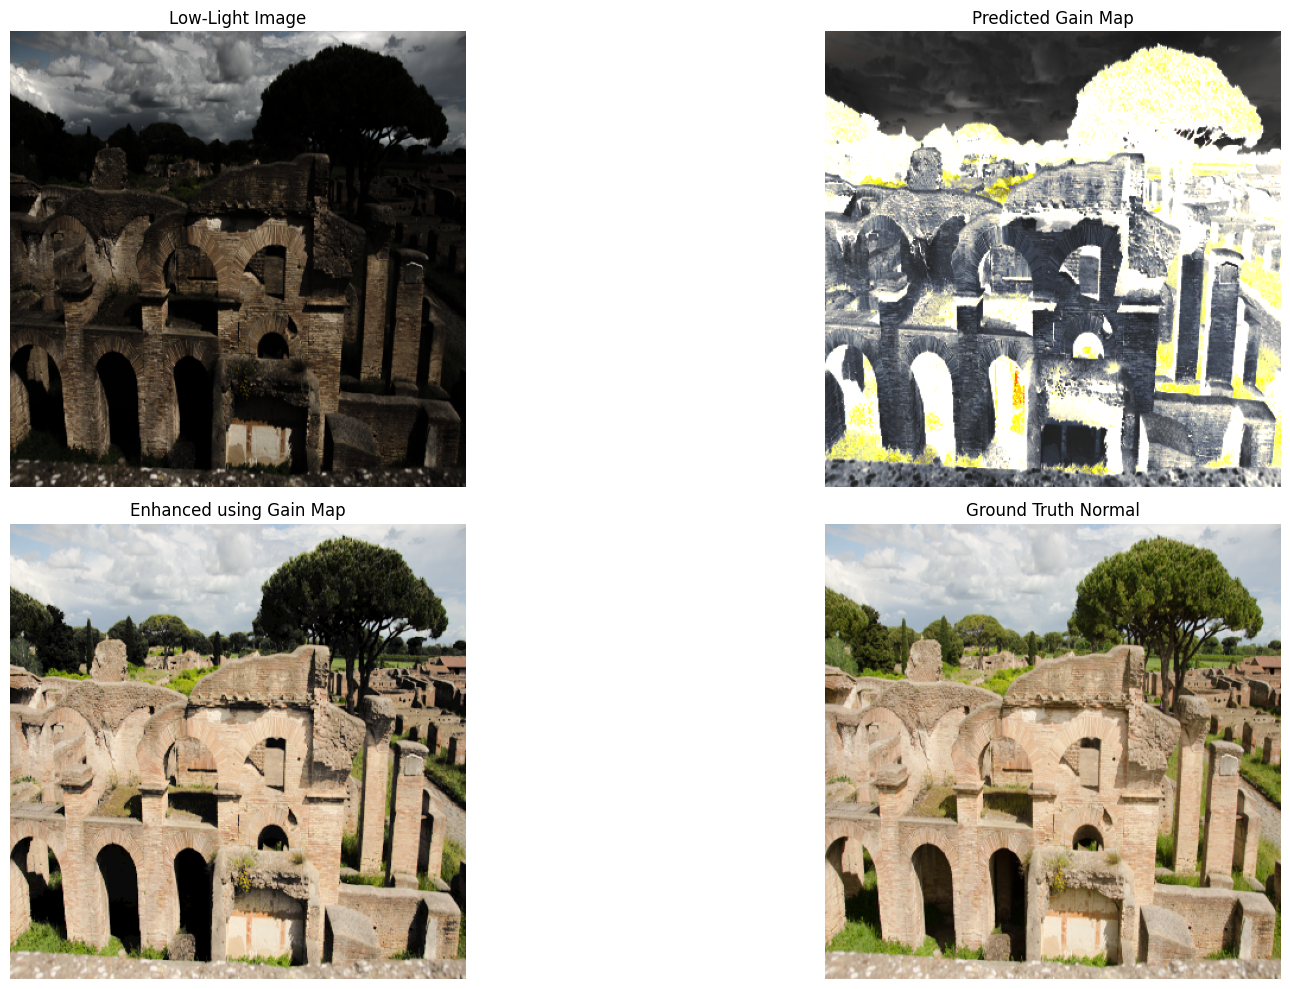

Gain Map Stats
---------------
Min Gain : 0.0
Max Gain : 10.0
Mean Gain: 5.8461175


In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Paths
# ==========================================
low_path = "LOL-v2/synthetic/train/low"
high_path = "LOL-v2/synthetic/train/normal"

image_names = sorted(os.listdir(low_path))

print("Total Images:", len(image_names))

# ==========================================
# Select image
# ==========================================
idx = 600

img_name = image_names[idx]

low_img_path = os.path.join(low_path, img_name)
high_img_path = os.path.join(high_path, img_name)

# ==========================================
# Read images
# ==========================================
low_img = cv2.imread(low_img_path)
high_img = cv2.imread(high_img_path)

# BGR -> RGB
low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

# Normalize to [0,1]
low = low_img.astype(np.float32) / 255.0
high = high_img.astype(np.float32) / 255.0

# ==========================================
# Gain Map Calculation
# ==========================================
epsilon = 1e-3

gain_map = high / (low + epsilon)

# Optional clipping
gain_map = np.clip(gain_map, 0, 10)

# ==========================================
# Reconstruct enhanced image
# ==========================================
enhanced = low * gain_map

# Clip values
enhanced = np.clip(enhanced, 0, 1)

# ==========================================
# Visualization
# ==========================================

plt.figure(figsize=(20, 10))

# ------------------------------------------
# Low-light Image
# ------------------------------------------
plt.subplot(2, 2, 1)
plt.imshow(low)
plt.title("Low-Light Image")
plt.axis("off")

# ------------------------------------------
# Gain Map Visualization
# ------------------------------------------
# Normalize gain map for display
gain_vis = gain_map / gain_map.max()

plt.subplot(2, 2, 2)
plt.imshow(gain_vis)
plt.title("Predicted Gain Map")
plt.axis("off")

# ------------------------------------------
# Reconstructed Enhanced Image
# ------------------------------------------
plt.subplot(2, 2, 3)
plt.imshow(enhanced)
plt.title("Enhanced using Gain Map")
plt.axis("off")

# ------------------------------------------
# Ground Truth
# ------------------------------------------
plt.subplot(2, 2, 4)
plt.imshow(high)
plt.title("Ground Truth Normal")
plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================
# Statistics
# ==========================================

print("Gain Map Stats")
print("---------------")
print("Min Gain :", gain_map.min())
print("Max Gain :", gain_map.max())
print("Mean Gain:", gain_map.mean())